In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# Load data
print("Loading data...")
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Reload original test data for segment labels
import pandas as pd
train_trans = pd.read_csv('train_transaction.csv')
train_id = pd.read_csv('train_identity.csv')
df = train_trans.merge(train_id, on='TransactionID', how='left')
df = df.copy()

# Reload model
from xgboost import XGBClassifier
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
model.fit(X_train, y_train, verbose=False)

# Get predictions on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
optimal_threshold = 0.83
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

print("Ready for bias analysis.")
print(f"Test set size: {len(y_test):,}")

Loading data...
Ready for bias analysis.
Test set size: 118,108


In [2]:
# Bias Analysis - Model performance across segments
# SR 11-7 requires testing model stability across subpopulations

# Align test indices with original dataframe
test_idx = y_test.index
df_test = df.iloc[test_idx].copy()
df_test['y_pred_proba'] = y_pred_proba
df_test['y_pred'] = y_pred
df_test['y_true'] = y_test.values

def segment_performance(df_seg, segment_col, min_fraud=50):
    """Calculate model performance metrics by segment."""
    results = []
    for segment, group in df_seg.groupby(segment_col):
        if group['y_true'].sum() < min_fraud:
            continue  # Skip segments with too few fraud cases
        try:
            auc = roc_auc_score(group['y_true'], group['y_pred_proba'])
            ap = average_precision_score(group['y_true'], group['y_pred_proba'])
            precision = precision_score(group['y_true'], group['y_pred'], zero_division=0)
            recall = recall_score(group['y_true'], group['y_pred'], zero_division=0)
            fraud_rate = group['y_true'].mean() * 100
            n = len(group)
            results.append({
                'Segment': segment,
                'N': n,
                'Fraud Rate (%)': round(fraud_rate, 2),
                'ROC-AUC': round(auc, 4),
                'Avg Precision': round(ap, 4),
                'Precision': round(precision, 4),
                'Recall': round(recall, 4)
            })
        except:
            continue
    return pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

# Segment 1: ProductCD
print("=== PERFORMANCE BY PRODUCT TYPE ===")
prod_perf = segment_performance(df_test, 'ProductCD')
print(prod_perf.to_string(index=False))

# Segment 2: card6 (credit vs debit)
print("\n=== PERFORMANCE BY CARD TYPE ===")
card_perf = segment_performance(df_test, 'card6')
print(card_perf.to_string(index=False))

# Segment 3: card4 (card network)
print("\n=== PERFORMANCE BY CARD NETWORK ===")
network_perf = segment_performance(df_test, 'card4')
print(network_perf.to_string(index=False))

=== PERFORMANCE BY PRODUCT TYPE ===
Segment     N  Fraud Rate (%)  ROC-AUC  Avg Precision  Precision  Recall
      H 19780            3.51   0.9417         0.6462     0.6696  0.5482
      S  2810            3.45   0.9375         0.6532     0.7297  0.5567
      R 18830            3.48   0.9355         0.6411     0.6941  0.5542
      W 63319            3.43   0.9343         0.6611     0.6911  0.5777
      C 13369            3.87   0.9328         0.6368     0.7236  0.5164

=== PERFORMANCE BY CARD TYPE ===
Segment     N  Fraud Rate (%)  ROC-AUC  Avg Precision  Precision  Recall
 credit 42222            3.49   0.9403         0.6634     0.7105  0.5577
  debit 75868            3.50   0.9333         0.6460     0.6826  0.5629

=== PERFORMANCE BY CARD NETWORK ===
         Segment     N  Fraud Rate (%)  ROC-AUC  Avg Precision  Precision  Recall
        discover  1767            3.17   0.9446         0.7129     0.7800  0.6964
american express  4152            3.59   0.9382         0.6529     0.710

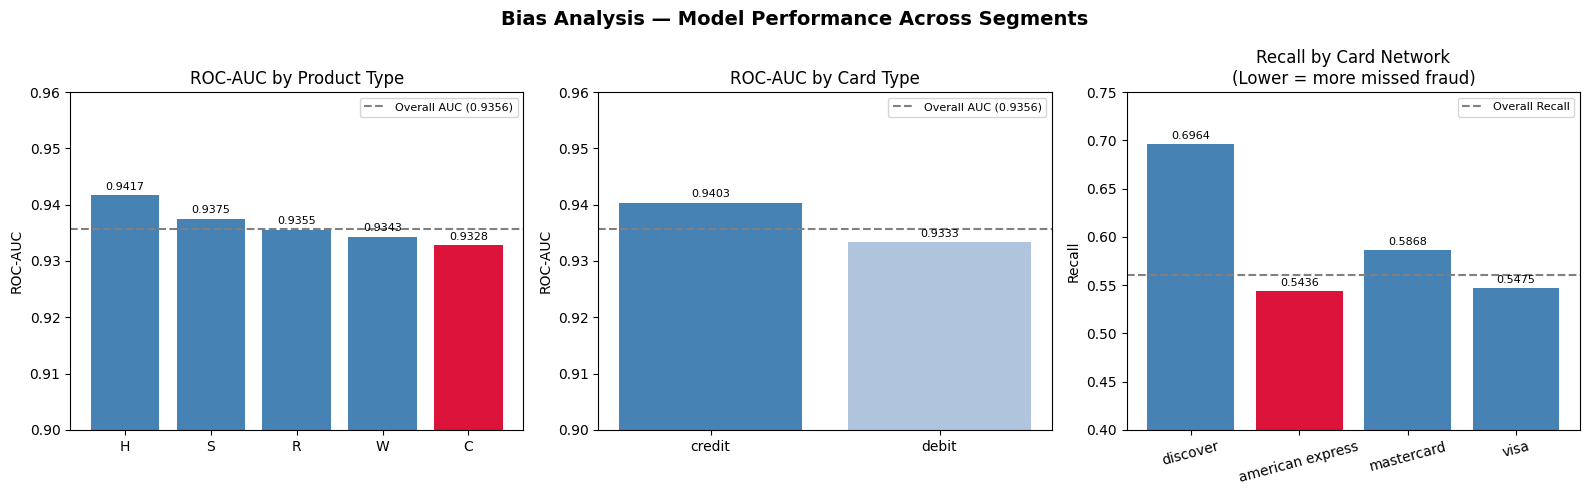

Saved: 11_bias_analysis.png


In [3]:
# Visualize bias analysis results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: ROC-AUC by ProductCD
colors = ['crimson' if x == min(prod_perf['ROC-AUC']) 
          else 'steelblue' for x in prod_perf['ROC-AUC']]
axes[0].bar(prod_perf['Segment'], prod_perf['ROC-AUC'], color=colors)
axes[0].axhline(y=0.9356, color='gray', linestyle='--', 
                label='Overall AUC (0.9356)')
axes[0].set_title('ROC-AUC by Product Type')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(0.90, 0.96)
axes[0].legend(fontsize=8)
for i, (seg, val) in enumerate(zip(prod_perf['Segment'], prod_perf['ROC-AUC'])):
    axes[0].text(i, val + 0.001, f'{val:.4f}', ha='center', fontsize=8)

# Plot 2: ROC-AUC by Card Type
colors2 = ['steelblue', 'lightsteelblue']
axes[1].bar(card_perf['Segment'], card_perf['ROC-AUC'], color=colors2)
axes[1].axhline(y=0.9356, color='gray', linestyle='--',
                label='Overall AUC (0.9356)')
axes[1].set_title('ROC-AUC by Card Type')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.90, 0.96)
axes[1].legend(fontsize=8)
for i, (seg, val) in enumerate(zip(card_perf['Segment'], card_perf['ROC-AUC'])):
    axes[1].text(i, val + 0.001, f'{val:.4f}', ha='center', fontsize=8)

# Plot 3: Recall by Card Network (bias check)
colors3 = ['crimson' if x == min(network_perf['Recall']) 
           else 'steelblue' for x in network_perf['Recall']]
axes[2].bar(network_perf['Segment'], network_perf['Recall'], color=colors3)
axes[2].axhline(y=recall_score(y_test, y_pred), color='gray', 
                linestyle='--', label=f'Overall Recall')
axes[2].set_title('Recall by Card Network\n(Lower = more missed fraud)')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0.40, 0.75)
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(fontsize=8)
for i, (seg, val) in enumerate(zip(network_perf['Segment'], network_perf['Recall'])):
    axes[2].text(i, val + 0.005, f'{val:.4f}', ha='center', fontsize=8)

plt.suptitle('Bias Analysis — Model Performance Across Segments', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_bias_analysis.png")